## Gas Porosimeter Measurement

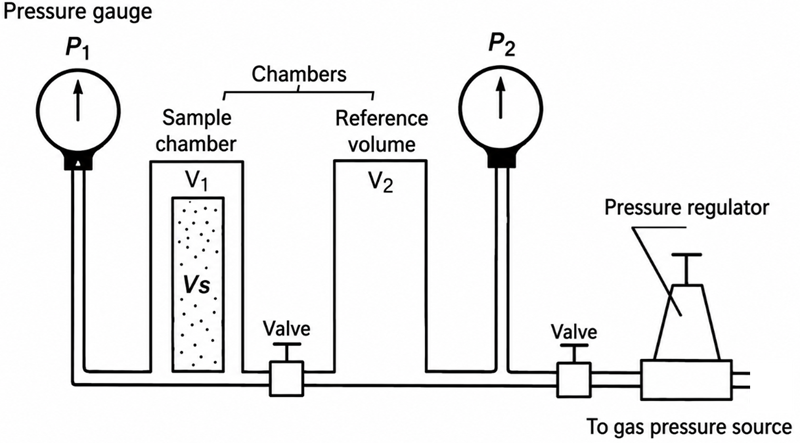


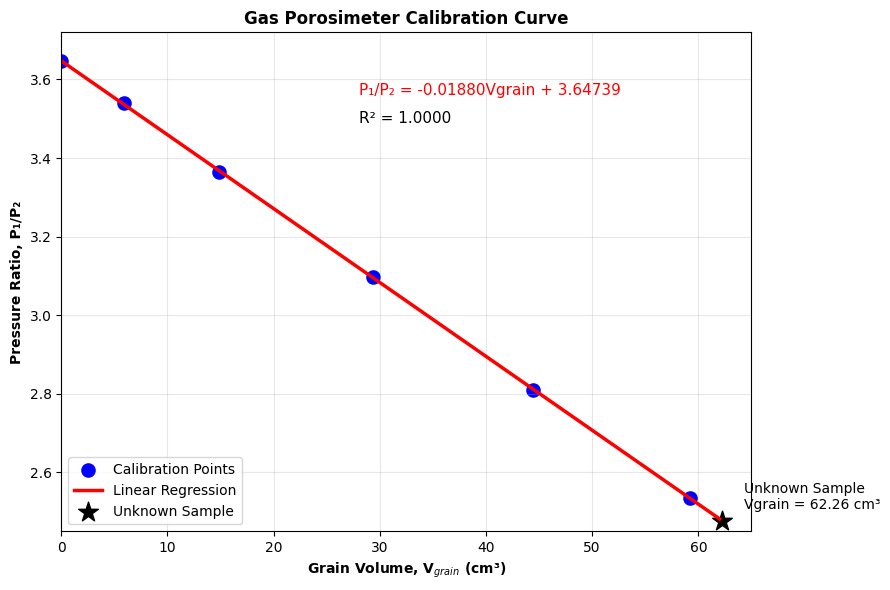


---------- CALIBRATION ----------
P1/P2 = -0.01880 × Vgrain + 3.64739
R² = 1.0000

---------- UNKNOWN SAMPLE ----------
P1 = 7.010 barg
P2 = 2.830 barg
P1/P2 = 2.477

---------- CORE PLUG ----------
Diameter = 3.750 cm
Length   = 6.600 cm

Bulk Volume  = 72.89 cm³
Grain Volume = 62.26 cm³

---------- POROSITY ----------
Porosity = 14.59 %


In [18]:
# Gas Porosimeter Calibration Curve & Porosity Calculation
# Code written by Sukru Merey
# 16/05/2026
# contact: sukrumerey@gmail.com

"""
In this Python code, the interconnected porosity of a core plug sample from the Southeastern Anatolia Region of Türkiye 
is measured using a gas porosimeter. Compared with other destructive porosity measurement techniques, this method is 
more practical and non-destructive.
This script:

1. Creates a gas porosimeter calibration curve
2. Calculates unknown grain volume
3. Calculates bulk volume of cylindrical core plug
4. Calculates porosity

Core Plug Dimensions:
    Diameter = 3.750 cm
    Length   = 6.600 cm
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -----------------------------
# CALIBRATION DATA
# -----------------------------
Vgrain = np.array([0.000, 5.938, 14.808, 29.395, 44.386, 59.175])  # cm³

P_ratio = np.array([3.646, 3.540, 3.365, 3.097, 2.811, 2.536])  # P1 (Initial Pressure in Reference Cell)/P2 (Final Pressure when sample & reference chamber are connected)

# -----------------------------
# CORE PLUG DIMENSIONS
# -----------------------------
diameter = 3.750   # cm
length = 6.600     # cm

radius = diameter / 2

# Bulk Volume (Cylinder)
Vbulk = np.pi * radius**2 * length

# -----------------------------
# LINEAR REGRESSION
# -----------------------------
X = Vgrain.reshape(-1,1)

model = LinearRegression()
model.fit(X, P_ratio)

a = model.coef_[0]
b = model.intercept_

r2 = model.score(X, P_ratio)

# -----------------------------
# UNKNOWN SAMPLE
# -----------------------------
P1 = 7.010   # barg
P2 = 2.830   # barg

y_unknown = P1 / P2

# Grain Volume Calculation
Vgrain_unknown = (y_unknown - b) / a

# -----------------------------
# POROSITY
# -----------------------------
# Porosity = (Vbulk - Vgrain) / Vbulk

porosity = ((Vbulk - Vgrain_unknown) / Vbulk) * 100

# -----------------------------
# REGRESSION LINE
# -----------------------------
x_line = np.linspace(0, 62, 300)

y_line = model.predict(x_line.reshape(-1,1))

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(9,6))

# Calibration points
plt.scatter(
    Vgrain,
    P_ratio,
    color='blue',
    s=90,
    label='Calibration Points'
)

# Regression line
plt.plot(
    x_line,
    y_line,
    color='red',
    linewidth=2.5,
    label='Linear Regression'
)

# Unknown sample
plt.scatter(
    Vgrain_unknown,
    y_unknown,
    color='black',
    marker='*',
    s=220,
    label='Unknown Sample'
)

# -----------------------------
# EQUATION ON FIGURE
# -----------------------------
plt.text(
    28,
    3.56,
    f"P₁/P₂ = {a:.5f}Vgrain + {b:.5f}",
    fontsize=11,
    color='red'
)

plt.text(
    28,
    3.49,
    f"R² = {r2:.4f}",
    fontsize=11
)

# Unknown sample annotation
plt.text(
    Vgrain_unknown + 2,
    y_unknown + 0.03,
    f"Unknown Sample\nVgrain = {Vgrain_unknown:.2f} cm³",
    fontsize=10
)

# -----------------------------
# AXES
# -----------------------------
plt.xlabel(
    "Grain Volume, V$_{grain}$ (cm³)",
    fontweight='bold'
)

plt.ylabel(
    "Pressure Ratio, P₁/P₂",
    fontweight='bold'
)

plt.title(
    "Gas Porosimeter Calibration Curve",
    fontweight='bold'
)

# Axis limits
plt.xlim(0, 65)
plt.ylim(2.45, 3.72)

# Grid
plt.grid(alpha=0.3)

# Legend
plt.legend(frameon=True)

# Better spacing
plt.tight_layout()

plt.show()

# -----------------------------
# RESULTS
# -----------------------------
print("\n---------- CALIBRATION ----------")

print(f"P1/P2 = {a:.5f} × Vgrain + {b:.5f}")

print(f"R² = {r2:.4f}")

print("\n---------- UNKNOWN SAMPLE ----------")

print(f"P1 = {P1:.3f} barg")
print(f"P2 = {P2:.3f} barg")

print(f"P1/P2 = {y_unknown:.3f}")

print("\n---------- CORE PLUG ----------")

print(f"Diameter = {diameter:.3f} cm")
print(f"Length   = {length:.3f} cm")

print(f"\nBulk Volume  = {Vbulk:.2f} cm³")

print(f"Grain Volume = {Vgrain_unknown:.2f} cm³")

print("\n---------- POROSITY ----------")

print(f"Porosity = {porosity:.2f} %")